<a href="https://colab.research.google.com/github/NikolaiMiranda/customer-segmentation-retail/blob/main/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [ ]:
import pandas as pd
from datetime import timedelta
from ucimlrepo import fetch_ucirepo
from sklearn.metrics import davies_bouldin_score
import numpy as np

Gather and clean the data:

In [164]:
# fetch dataset
online_retail = fetch_ucirepo(id=352)

# create a dataframe to hold the data
# reading through the documentation for ucimlrepo we find that our data is split into dataframe labeled "ids" and "features"
# we will joing those together to form one dataframe
# Check that both dataframes are the same length and then join them
print(len(online_retail.data.ids) == len(online_retail.data.features))
df = online_retail.data.ids.join(online_retail.data.features)

True


In [165]:
# View the data
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [166]:
# Check if we have null values
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [167]:
# We have missing cutomer IDs
# We remove these since we need the IDs to match customers to their purchases and segment them
df = df.dropna(subset=['CustomerID'])

# Check to make sure null values have been discarded
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [168]:
# The documentation states that if an order is cancelled the InvoiceNo will start with a 'c'
# We will remove all canceled orders from the data since we want to segment customers based on their purchases.
# Let us look at an example of a cancelled order.
df[df['CustomerID'] == 12346]
# We must match all cancelled orders to their original orders and then remove them.
# If the cancelled quanitity equals the original quanitity, delete both orders.
# If the cancelled quantity is less than the original quantity, subtract the cancelled quantity from the original quanitity and delete the cancelled transaction.

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1/18/2011 10:01,1.04,12346.0,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1/18/2011 10:17,1.04,12346.0,United Kingdom


In [175]:
import pandas as pd

def adjust_cancellations(df):
    """
    Adjust quantities in a DataFrame by subtracting matching cancellations.
    If quantity becomes zero or negative after cancellation, the row is removed.

    Parameters:
        df (pd.DataFrame): Must contain 'InvoiceNo', 'StockCode', 'Description', 'Quantity',
                           'UnitPrice', 'CustomerID', and 'Country' columns.

    Returns:
        pd.DataFrame: Adjusted DataFrame with cancellations removed/quantities updated.
    """
    # Separate cancellations and originals
    df_cancel = df[df['InvoiceNo'].str.startswith('C')].copy()
    df_cancel['Quantity'] = df_cancel['Quantity'].abs()

    df_original = df[~df['InvoiceNo'].str.startswith('C')].copy()

    # Group cancellations so multiple cancels get summed together
    matching_cols = ['StockCode', 'Description', 'UnitPrice', 'CustomerID', 'Country']
    df_cancel_grouped = (
        df_cancel
        .groupby(matching_cols, as_index=False)['Quantity']
        .sum()
        .rename(columns={'Quantity': 'Quantity_cancel'})
    )

    # Merge grouped cancellations into originals
    df_adjusted = pd.merge(
        df_original,
        df_cancel_grouped,
        on=matching_cols,
        how='left'
    )

    # Adjust quantities
    df_adjusted['Quantity_cancel'] = df_adjusted['Quantity_cancel'].fillna(0)
    df_adjusted['Quantity'] = df_adjusted['Quantity'] - df_adjusted['Quantity_cancel']

    # Remove zero/negative quantities
    df_adjusted = df_adjusted[df_adjusted['Quantity'] > 0].copy()

    # Drop temp col & reset index
    df_adjusted.drop(columns=['Quantity_cancel'], inplace=True)
    df_adjusted.reset_index(drop=True, inplace=True)

    return df_adjusted

In [176]:
# Testing
def test_adjust_cancellations():
    # 1️⃣ Create synthetic test data
    data = [
        ['10001', 'A1', 'Widget', 10, '2025-08-01', 2.0, 111, 'UK'],   # full cancel
        ['10002', 'B2', 'Gadget', 5,  '2025-08-01', 3.0, 222, 'UK'],   # partial cancel
        ['10003', 'C3', 'Thingy', 8,  '2025-08-01', 4.0, 333, 'UK'],   # no cancel
        ['C10001', 'A1', 'Widget', -10, '2025-08-02', 2.0, 111, 'UK'], # full cancel
        ['C10002', 'B2', 'Gadget', -2,  '2025-08-02', 3.0, 222, 'UK'], # first partial cancel
        ['C10002b','B2', 'Gadget', -1,  '2025-08-03', 3.0, 222, 'UK'], # second partial cancel
    ]
    df = pd.DataFrame(data, columns=[
        'InvoiceNo', 'StockCode', 'Description', 'Quantity',
        'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country'
    ])

    print("=== ORIGINAL DATA ===")
    print(df)

    # 2️⃣ Run function
    df_adjusted = adjust_cancellations(df)

    print("\n=== ADJUSTED DATA ===")
    print(df_adjusted)

    # 3️⃣ Change log (before → after quantities)
    print("\n=== CHANGE LOG ===")
    for code in df['StockCode'].unique():
        original_qty = df[df['StockCode'] == code]['Quantity'][~df['InvoiceNo'].str.startswith('C')].sum()
        adjusted_qty = df_adjusted[df_adjusted['StockCode'] == code]['Quantity'].sum() if code in df_adjusted['StockCode'].values else 0
        print(f"{code}: {original_qty} → {adjusted_qty}")

    # 4️⃣ Automated Checks
    print("\n=== TEST RESULTS ===")
    tests_passed = True

    # Expected results
    expected = {
        'A1': None,     # fully cancelled, should be removed
        'B2': 2,        # started with 5, cancelled total 3
        'C3': 8         # unchanged
    }

    # Check 1: No cancellations remain
    if (df_adjusted['InvoiceNo'].str.startswith('C').any()):
        print("❌ Cancellations still present in adjusted data!")
        tests_passed = False

    # Check 2: Quantities match expectations
    for stock, qty in expected.items():
        actual_qtys = df_adjusted.loc[df_adjusted['StockCode'] == stock, 'Quantity']
        if qty is None:
            if not actual_qtys.empty:
                print(f"❌ {stock} should be removed but is still present.")
                tests_passed = False
        else:
            if actual_qtys.empty or actual_qtys.iloc[0] != qty:
                print(f"❌ {stock} expected qty {qty} but got {actual_qtys.iloc[0] if not actual_qtys.empty else 'MISSING'}.")
                tests_passed = False

    # Check 3: No zero-quantity rows
    if (df_adjusted['Quantity'] == 0).any():
        print("❌ Zero quantities found in adjusted data!")
        tests_passed = False

    if tests_passed:
        print("✅ All tests passed!")
    else:
        print("⚠ Some tests failed.")


# Run the test in Colab
test_adjust_cancellations()

=== ORIGINAL DATA ===
  InvoiceNo StockCode Description  Quantity InvoiceDate  UnitPrice  \
0     10001        A1      Widget        10  2025-08-01        2.0   
1     10002        B2      Gadget         5  2025-08-01        3.0   
2     10003        C3      Thingy         8  2025-08-01        4.0   
3    C10001        A1      Widget       -10  2025-08-02        2.0   
4    C10002        B2      Gadget        -2  2025-08-02        3.0   
5   C10002b        B2      Gadget        -1  2025-08-03        3.0   

   CustomerID Country  
0         111      UK  
1         222      UK  
2         333      UK  
3         111      UK  
4         222      UK  
5         222      UK  

=== ADJUSTED DATA ===
  InvoiceNo StockCode Description  Quantity InvoiceDate  UnitPrice  \
0     10002        B2      Gadget       2.0  2025-08-01        3.0   
1     10003        C3      Thingy       8.0  2025-08-01        4.0   

   CustomerID Country  
0         222      UK  
1         333      UK  

=== CHANGE L

In [ ]:
# Make adjustments
df = adjust_cancellations(df)

In [ ]:
# Look for likely outliers and remove them as well
# Discovered that some products has UnitPrice = 0
print(len(df[df['UnitPrice'] <= 0]))
# Remove products with UnitPrice = 0
df = df[df['UnitPrice'] > 0]
print(len(df[df['UnitPrice'] <= 0]))

40
0


Feature engineering:

In [ ]:
# Create a total spend variable
df.loc[:, 'TotalSpend'] = df['Quantity'] * df['UnitPrice']

In [ ]:
# Compute a reference date to use to create a recency variable
# We will calculate recency in terms of number of days from the "current date"
# We willuse the last day in the data set as the "current date"

# Make sure InvoiceDate is of type datetime
df.loc[:, 'InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
# Create a date to reference all other dates against
reference_date = df['InvoiceDate'].max()

In [ ]:
# Create a summary dataframe using our additional features
customer_df = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days), # Days since last purchase
    Frequency=('InvoiceNo', 'nunique'), # Number of unique invoices
    Monetary=('TotalSpend', 'sum'), # Total spend
    AvgQuantity = ('Quantity', 'mean'), # Average quantity per transaction
    ProductCount = ('StockCode', 'nunique'), # Number of unique products purchased
    Country = ('Country', lambda x: x.mode()[0]) # Most common country
)


customer_df.head()

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country
CustomerID,,,,,,
12347.0,1,7,4310.00,13.505495,103,Iceland
12348.0,74,4,1797.24,75.516129,22,Finland
12349.0,18,1,1757.55,8.643836,73,Italy
12350.0,309,1,334.40,11.588235,17,Norway
12352.0,35,6,1405.28,5.895522,51,Norway


Segmentation using K-means:

In [177]:
# Feature Scaling for K-Means
from sklearn.preprocessing import StandardScaler

# Select the RFM features for clustering
features = customer_df[['Recency', 'Frequency', 'Monetary', 'AvgQuantity', 'ProductCount']].copy()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
customer_df_scaled = scaler.fit_transform(features)

# Convert the scaled array back to a DataFrame for easier handling
customer_df_scaled = pd.DataFrame(customer_df_scaled, columns=features.columns, index=customer_df.index)

customer_df_scaled.head() # Display the first few rows of the scaled data

,Recency,Frequency,Monetary,AvgQuantity,ProductCount
CustomerID,,,,,
12347.0,-0.906606,0.370453,0.297766,-0.074720,0.493992
12348.0,-0.179013,-0.028868,-0.011836,0.502970,-0.462630
12349.0,-0.737166,-0.428190,-0.016726,-0.120011,0.139687
12350.0,2.163240,-0.428190,-0.192075,-0.092581,-0.521681
12352.0,-0.567727,0.237346,-0.060130,-0.145614,-0.120136


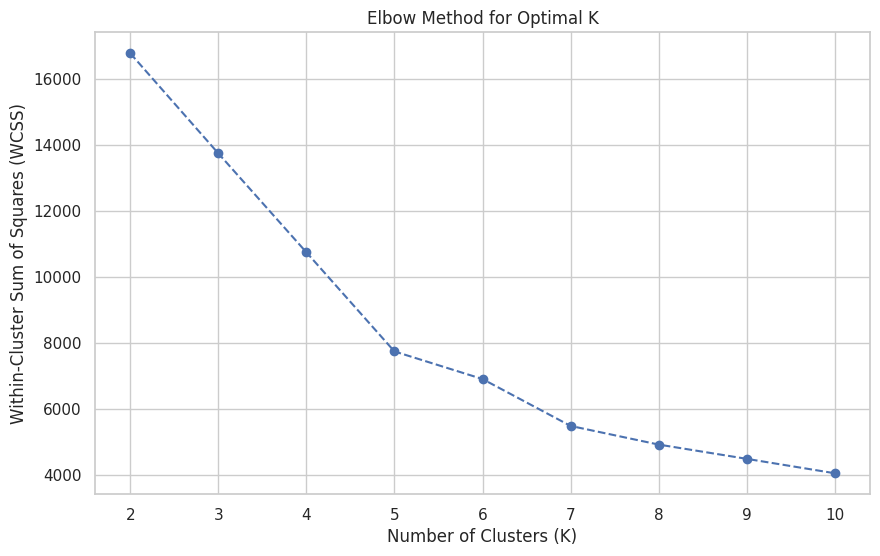

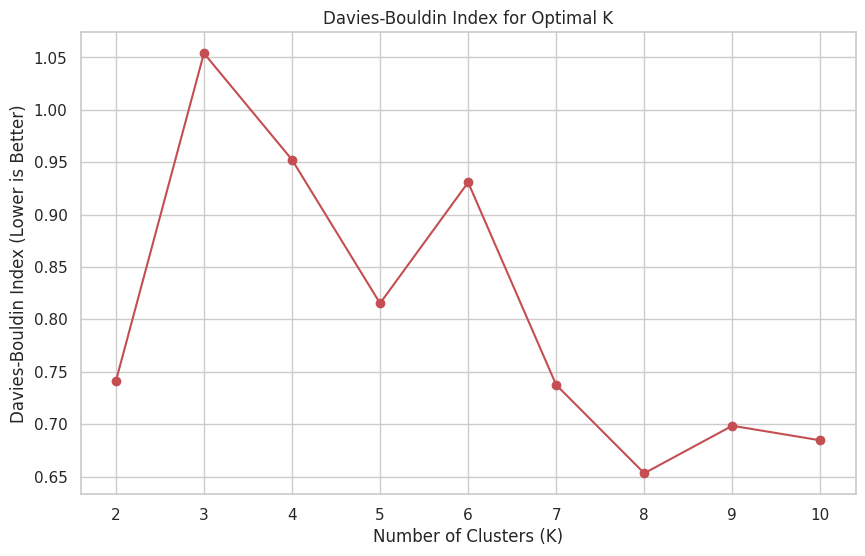

In [205]:
# Determine optimal number of clusters using the Elbow Method and Davies-Bouldin Index
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

wcss = []
dbi_scores = []
k_range = range(2, 11)  # Test 2 to 10 clusters

for k in k_range:
    # Initialize KMeans
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init='auto', max_iter=30000, random_state=42)
    kmeans.fit(customer_df_scaled)

    # Elbow method: within-cluster sum of squares
    wcss.append(kmeans.inertia_)

    # Davies-Bouldin Index: lower is better
    dbi = davies_bouldin_score(customer_df_scaled, kmeans.labels_)
    dbi_scores.append(dbi)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

# Plot the Davies-Bouldin Index graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, dbi_scores, marker='o', linestyle='-', color='r')
plt.title('Davies-Bouldin Index for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index (Lower is Better)')
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [206]:
# Apply K-Means Clustering with K=5
from sklearn.cluster import KMeans

# Initialize KMeans with the chosen K (5)
# n_init='auto' is the modern default for n_init
kmeans = KMeans(n_clusters=5, init='k-means++', n_init='auto', max_iter=30000, random_state=42)

# Fit KMeans to the scaled RFM data and get cluster labels
customer_df['Cluster_KMeans'] = kmeans.fit_predict(customer_df_scaled)

customer_df.head() # Display rfm_df with the new Cluster_KMeans column

,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans
CustomerID,,,,,,,
12347.0,1,7,4310.00,13.505495,103,Iceland,4
12348.0,74,4,1797.24,75.516129,22,Finland,4
12349.0,18,1,1757.55,8.643836,73,Italy,4
12350.0,309,1,334.40,11.588235,17,Norway,0
12352.0,35,6,1405.28,5.895522,51,Norway,4


In [207]:
# Analyze K-Means Cluster Characteristics
# Use customer_df (original, unscaled values) for meaningful averages
customer_df2 = customer_df.reset_index()
kmeans_cluster_analysis = customer_df2.groupby('Cluster_KMeans').agg(
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    CustomerCount=('CustomerID', 'count'), # Assuming CustomerID is now a regular column due to previous reset_index
    AvgQuantity=('AvgQuantity', 'mean'),
    AvgProductCount=('ProductCount', 'mean')
).sort_values(by='AvgMonetary', ascending=False) # Sort by Monetary for easier comparison

kmeans_cluster_analysis

,AvgRecency,AvgFrequency,AvgMonetary,CustomerCount,AvgQuantity,AvgProductCount
Cluster_KMeans,,,,,,
2,4.300000,95.300000,124751.664000,10,66.117109,810.500000
1,15.489933,14.378076,7192.546980,447,18.170842,209.006711
3,149.400000,1.900000,3600.771000,10,1879.350000,1.600000
4,45.294369,3.276907,1131.690069,2806,17.365458,49.088026
0,249.212928,1.562738,488.984383,1052,15.965712,24.032319


In [202]:
customer_df2[customer_df2['Cluster_KMeans'] == 3]

,CustomerID,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans
410,12875.0,142,2,343.23,1009.5,1,United Kingdom,3
593,13135.0,196,1,3096.00,4300.0,1,United Kingdom,3
1657,14609.0,71,4,601.56,1756.5,2,United Kingdom,3
2021,15118.0,133,1,244.80,1440.0,1,United Kingdom,3
2079,15195.0,2,1,3861.00,1404.0,1,United Kingdom,3
2494,15749.0,234,2,18311.50,1440.0,4,United Kingdom,3
2893,16308.0,37,4,2560.00,2000.0,1,United Kingdom,3
3221,16754.0,371,1,2002.40,2140.0,2,United Kingdom,3
4180,18087.0,97,2,4055.72,1953.5,2,United Kingdom,3
4213,18133.0,211,1,931.50,1350.0,1,United Kingdom,3


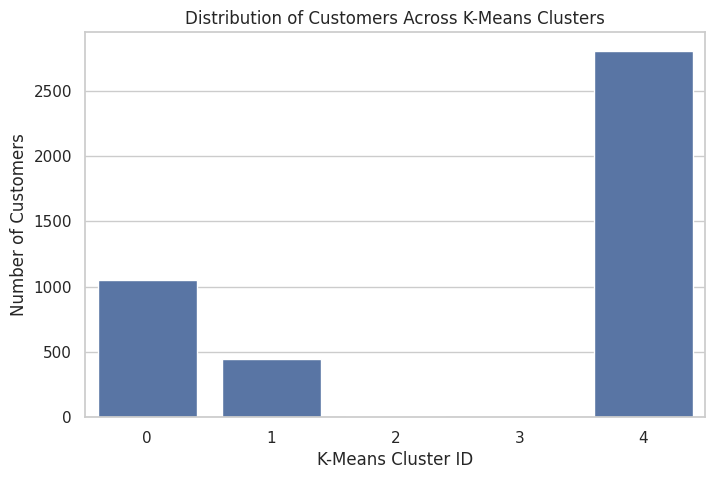

In [204]:
# Visualize K-Means Cluster Sizes
plt.figure(figsize=(8, 5))
sns.countplot(data=customer_df2, x='Cluster_KMeans')
plt.title('Distribution of Customers Across K-Means Clusters')
plt.xlabel('K-Means Cluster ID')
plt.ylabel('Number of Customers')
plt.show()

In [190]:
# Map K-Means Cluster IDs to descriptive names

# IMPORTANT: VERIFY THESE MAPPINGS AGAINST YOUR ACTUAL kmeans_cluster_analysis OUTPUT
# The cluster IDs (0, 1, 2) are arbitrary and can change with each run.
# Adjust the dictionary below based on the AvgRecency, AvgFrequency, and AvgMonetary for YOUR Cluster 0, 1, and 2.

# Example mapping (adjust based on your actual output):
# Based on my interpretation in the text above:
# Assuming Cluster 0 is At-Risk/Lapsed
# Assuming Cluster 1 is Champions/Loyal
# Assuming Cluster 2 is Potential/Developing
cluster_name_mapping = {
    0: 'Avg',
    1: 'At-Risk',
    2: 'Loyalists',
    3: 'Elite Members'
}

customer_df2['KMeans_Cluster_Name'] = customer_df2['Cluster_KMeans'].map(cluster_name_mapping)

customer_df2.head() # Display rfm_df with the new KMeans_Cluster_Name column

,CustomerID,Recency,Frequency,Monetary,AvgQuantity,ProductCount,Country,Cluster_KMeans,KMeans_Cluster_Name
0,12347.0,1,7,4310.00,13.505495,103,Iceland,4,NaN
1,12348.0,74,4,1797.24,75.516129,22,Finland,4,NaN
2,12349.0,18,1,1757.55,8.643836,73,Italy,4,NaN
3,12350.0,309,1,334.40,11.588235,17,Norway,0,Avg
4,12352.0,35,6,1405.28,5.895522,51,Norway,4,NaN


In [191]:
# Count customers in each named K-Means cluster
customer_df2['KMeans_Cluster_Name'].value_counts()

,count
KMeans_Cluster_Name,
Avg,1052
At-Risk,447
Loyalists,10
Elite Members,10
